# Arco Narrativo: Contar la historia con datos

En las semanas anteriores analizamos los alojamientos (EDA), los agrupamos en segmentos (clustering) y entrenamos modelos para predecir y clasificar (supervisado). Ahora conectamos todo en una sola historia, organizada según las decisiones que necesita tomar quien va a invertir.

En lugar de procesar los datos de nuevo, nos conectamos directamente a las colecciones que ya guardamos en MongoDB: los datos limpios del EDA y los datos con la etiqueta del cluster.

## El contexto comercial y la recuperación de datos

In [1]:
import os
from dotenv import load_dotenv
from pyspark.sql import SparkSession
import pyspark.sql.functions as F

load_dotenv()
MONGO_URI = os.getenv("MONGO_URI")

spark = SparkSession.builder \
    .appName("Storytelling_Final") \
    .config("spark.mongodb.read.connection.uri", MONGO_URI) \
    .config("spark.mongodb.write.connection.uri", MONGO_URI) \
    .getOrCreate()

df_completos = spark.read.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "processed_data") \
    .load()

df_historico = spark.read.format("mongodb") \
    .option("database", "proyecto_bigdata") \
    .option("collection", "datos_clusters") \
    .load()

total_registros = df_historico.count()
print(f"Conexión establecida. Recuperamos {total_registros} alojamientos del histórico.")

Conexión establecida. Recuperamos 3584 alojamientos del histórico.


## Exportar los datos para el dashboard

Guardamos los datos en un CSV liviano que alimentará el dashboard interactivo (Streamlit) de la Semana 15. Incluimos las columnas que usan los tres niveles, junto con la etiqueta del cluster.

In [2]:
df_dashboard = df_historico.select(
    "nombre_hotel", "ciudad", "tipo_alojamiento",
    "precio_clp", "puntuacion", "prediction")

df_dashboard.toPandas().to_csv("datos_alojamientos_dashboard.csv", index=False)
print("Datos exportados a datos_alojamientos_dashboard.csv")

Datos exportados a datos_alojamientos_dashboard.csv


# Acto 1: El diagnóstico inicial

Analizamos los datos desde la perspectiva de quien decide una inversión, en tres niveles de decisión. Cada indicador responde una pregunta distinta del negocio.

## Nivel 1: Estratégico

Concentración del mercado por ciudad: cuántos alojamientos hay en cada ciudad y qué porcentaje del total representan. Esto muestra dónde está la mayor oferta (más competencia) y dónde la oferta es menor (posible oportunidad de inversión).

In [3]:
total_aloj = df_completos.count()

kpi_estrategico = df_completos.groupBy("ciudad") \
    .agg(
        F.count("ciudad").alias("Cantidad_Alojamientos"),
        F.round((F.count("ciudad") / total_aloj) * 100, 2).alias("Participacion_Porcentaje")
    ).orderBy(F.desc("Cantidad_Alojamientos"))

print("CONCENTRACIÓN DE MERCADO POR CIUDAD")
kpi_estrategico.show(20, truncate=False)

CONCENTRACIÓN DE MERCADO POR CIUDAD
+--------------+---------------------+------------------------+
|ciudad        |Cantidad_Alojamientos|Participacion_Porcentaje|
+--------------+---------------------+------------------------+
|Santiago      |229                  |6.39                    |
|Valparaiso    |221                  |6.17                    |
|Puerto Montt  |192                  |5.36                    |
|Valdivia      |190                  |5.3                     |
|Vina del Mar  |187                  |5.22                    |
|Antofagasta   |187                  |5.22                    |
|La Serena     |185                  |5.16                    |
|Iquique       |184                  |5.13                    |
|Concepcion    |184                  |5.13                    |
|Puerto Varas  |180                  |5.02                    |
|Arica         |178                  |4.97                    |
|Chillan       |174                  |4.85                    |
|Pun

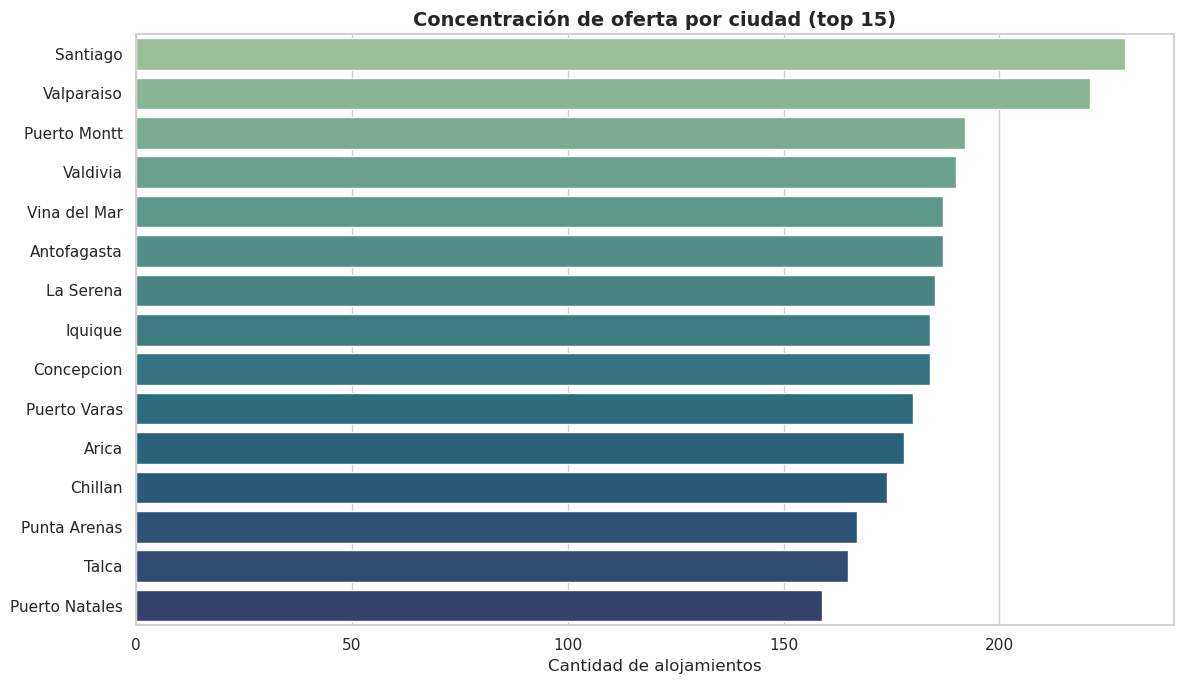

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

df_est = kpi_estrategico.toPandas().head(15)

plt.figure(figsize=(12, 7))
sns.set_theme(style="whitegrid")
ax = sns.barplot(x="Cantidad_Alojamientos", y="ciudad", data=df_est,
                 hue="ciudad", palette="crest", legend=False)
plt.title("Concentración de oferta por ciudad (top 15)", fontsize=14, fontweight="bold")
plt.xlabel("Cantidad de alojamientos")
plt.ylabel("")
plt.tight_layout(); plt.show()

## Nivel 2: Táctico

Dispersión de precios por tipo de alojamiento: precio mínimo, promedio, máximo y desviación. Muestra qué tipo de alojamiento es más caro, cuál más barato y en cuál los precios varían más (más riesgo o más margen).

In [5]:
kpi_tactico = df_completos.groupBy("tipo_alojamiento") \
    .agg(
        F.round(F.min("precio_clp"), 0).alias("Precio_Minimo"),
        F.round(F.avg("precio_clp"), 0).alias("Precio_Promedio"),
        F.round(F.max("precio_clp"), 0).alias("Precio_Maximo"),
        F.round(F.stddev("precio_clp"), 0).alias("Desviacion_Precios")
    ).orderBy(F.desc("Precio_Promedio"))

print("DISPERSIÓN DE PRECIOS POR TIPO DE ALOJAMIENTO")
kpi_tactico.show(truncate=False)

DISPERSIÓN DE PRECIOS POR TIPO DE ALOJAMIENTO
+----------------+-------------+---------------+-------------+------------------+
|tipo_alojamiento|Precio_Minimo|Precio_Promedio|Precio_Maximo|Desviacion_Precios|
+----------------+-------------+---------------+-------------+------------------+
|hotel           |21844.0      |110410.0       |229236.0     |51051.0           |
|casa/cabana     |21844.0      |89940.0        |229344.0     |34488.0           |
|apartamento     |22800.0      |83634.0        |226672.0     |32732.0           |
|hostal          |21844.0      |47521.0        |227400.0     |37841.0           |
+----------------+-------------+---------------+-------------+------------------+



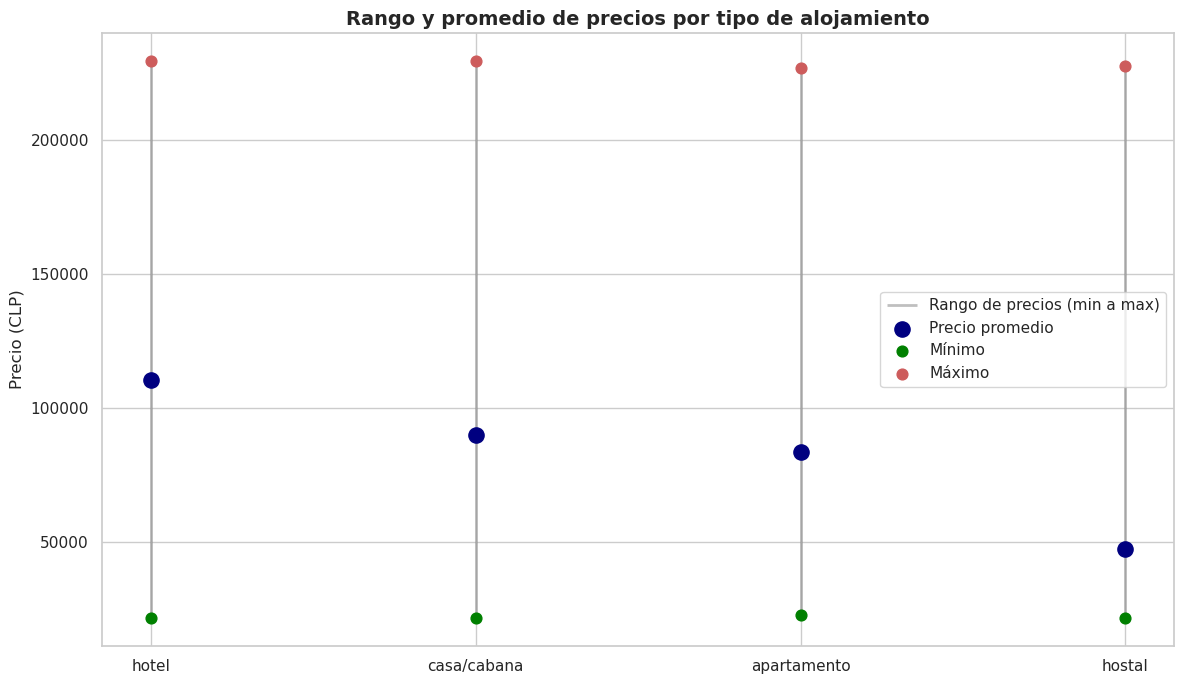

In [6]:
df_tac = kpi_tactico.toPandas()

plt.figure(figsize=(12, 7))
plt.vlines(x=df_tac["tipo_alojamiento"], ymin=df_tac["Precio_Minimo"], ymax=df_tac["Precio_Maximo"],
           colors="gray", alpha=0.5, linewidth=2, label="Rango de precios (min a max)")
plt.scatter(df_tac["tipo_alojamiento"], df_tac["Precio_Promedio"], color="navy", s=120, zorder=3, label="Precio promedio")
plt.scatter(df_tac["tipo_alojamiento"], df_tac["Precio_Minimo"], color="green", s=60, zorder=3, label="Mínimo")
plt.scatter(df_tac["tipo_alojamiento"], df_tac["Precio_Maximo"], color="indianred", s=60, zorder=3, label="Máximo")
plt.title("Rango y promedio de precios por tipo de alojamiento", fontsize=14, fontweight="bold")
plt.ylabel("Precio (CLP)")
plt.legend()
plt.tight_layout(); plt.show()

## Nivel 3: Operacional

Salud de la reputación: cuántos alojamientos hay en cada rango de puntuación. Los rangos más bajos (en rojo y naranjo) son las alertas, los alojamientos con menor calidad percibida dentro de los datos. Permite ver de un vistazo cuánta oferta está en la zona de menor evaluación.

Como en la limpieza del EDA se descartaron las puntuaciones bajas, la calidad arranca desde 7.0; aun así se observan diferencias entre los alojamientos mejor y peor evaluados.

In [7]:
UMBRAL_PUNTUACION = 7.5

kpi_alertas = df_completos.filter(F.col("puntuacion") < UMBRAL_PUNTUACION) \
    .select("nombre_hotel", "ciudad", "tipo_alojamiento", "precio_clp", "puntuacion") \
    .orderBy("puntuacion")

print(f"ALERTAS DE PUNTUACIÓN BAJA (menor a {UMBRAL_PUNTUACION}). Total: {kpi_alertas.count()}")
kpi_alertas.show(10, truncate=False)

ALERTAS DE PUNTUACIÓN BAJA (menor a 7.5). Total: 559
+------------------------------+----------+----------------+----------+----------+
|nombre_hotel                  |ciudad    |tipo_alojamiento|precio_clp|puntuacion|
+------------------------------+----------+----------------+----------+----------+
|Cabañas Costanera Valdivia    |Valdivia  |casa/cabana     |61092.0   |6.6       |
|Hostal Costanera Valdivia     |Valdivia  |hostal          |43414.0   |6.6       |
|Cabañas Del Mar Valdivia      |Valdivia  |casa/cabana     |91361.0   |6.6       |
|Apart Hotel Del Mar Copiapo   |Copiapo   |apartamento     |80630.0   |6.6       |
|Hostal Central Concepcion     |Concepcion|hostal          |29582.0   |6.6       |
|Apart Hotel Sur La Serena     |La Serena |apartamento     |108461.0  |6.6       |
|Hostal Cactus Copiapo         |Copiapo   |hostal          |29550.0   |6.6       |
|Cabañas Central La Serena     |La Serena |casa/cabana     |118346.0  |6.6       |
|Hostal Sol de Atacama         |Co

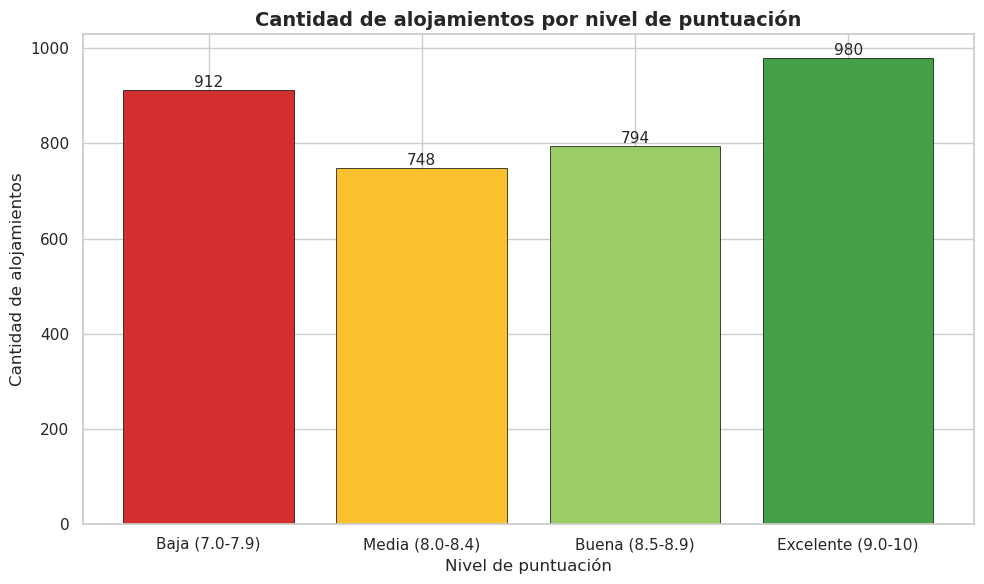

In [8]:
import pandas as pd

df_op = df_completos.select("puntuacion").toPandas()

rangos = [7.0, 8.0, 8.5, 9.0, 10.01]
etiquetas = ["Baja (7.0-7.9)", "Media (8.0-8.4)", "Buena (8.5-8.9)", "Excelente (9.0-10)"]
df_op["rango"] = pd.cut(df_op["puntuacion"], bins=rangos, labels=etiquetas, right=False)
conteo = df_op["rango"].value_counts().sort_index()

colores = ["#D32F2F", "#FBC02D", "#9CCC65", "#43A047"]

plt.figure(figsize=(10, 6))
bars = plt.bar(conteo.index.astype(str), conteo.values, color=colores, edgecolor="black", linewidth=0.5)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f"{int(h)}", ha="center", va="bottom", fontsize=11)
plt.title("Cantidad de alojamientos por nivel de puntuación", fontsize=14, fontweight="bold")
plt.xlabel("Nivel de puntuación")
plt.ylabel("Cantidad de alojamientos")
plt.tight_layout(); plt.show()

# Acto 2: El descubrimiento del mercado (segmentación)

Con el clustering descubrimos que los alojamientos se agrupan en tres segmentos. Esta tabla resume cada uno: cuántos alojamientos tiene, qué porcentaje del mercado representa y su precio promedio.

In [9]:
resumen_clusters = df_historico.groupBy("prediction") \
    .agg(
        F.count("prediction").alias("Cantidad_Alojamientos"),
        F.round((F.count("prediction") / total_registros) * 100, 2).alias("Porcentaje_Mercado"),
        F.round(F.avg("precio_clp"), 0).alias("Precio_Promedio"),
        F.round(F.avg("puntuacion"), 2).alias("Puntuacion_Promedio")
    ).orderBy("prediction")

print("RESUMEN DE LOS SEGMENTOS (CLUSTERS)")
resumen_clusters.show(truncate=False)

RESUMEN DE LOS SEGMENTOS (CLUSTERS)
+----------+---------------------+------------------+---------------+-------------------+
|prediction|Cantidad_Alojamientos|Porcentaje_Mercado|Precio_Promedio|Puntuacion_Promedio|
+----------+---------------------+------------------+---------------+-------------------+
|0         |1534                 |42.8              |68069.0        |8.98               |
|1         |1217                 |33.96             |67048.0        |7.56               |
|2         |833                  |23.24             |167145.0       |8.52               |
+----------+---------------------+------------------+---------------+-------------------+



Los tres segmentos, descritos según lo que muestran los datos recopilados (sin afirmar categorías absolutas, porque los precios provienen de plataformas distintas que no son directamente comparables):

- **Cluster 0** — Precio bajo y puntuación alta en los datos recopilados. Es el segmento más numeroso y el más atractivo para invertir: buena calidad percibida sin precios altos. Se concentra en ciudades como Valparaíso, Valdivia, Iquique, La Serena, Chillán, Punta Arenas, Puerto Varas y Puerto Montt.
- **Cluster 1** — Precio bajo y puntuación media. Mismo nivel de precio que el anterior pero con peor evaluación; hay margen de mejora en calidad. Más presente en la zona norte (Antofagasta, Arica).
- **Cluster 2** — Precio alto y puntuación alta. El segmento más caro y minoritario, concentrado en Santiago, Concepción y Viña del Mar.

El hallazgo central para la inversión: el Cluster 0 logra mejor puntuación que el segmento de precio alto cobrando bastante menos, lo que indica que el precio elevado no garantiza una mejor experiencia. Las ciudades del Cluster 0 ofrecen la mejor relación entre precio y calidad dentro de los datos analizados.

# Cierre

El recorrido completo del proyecto responde la pregunta de inversión: a partir de datos reales de múltiples plataformas, limpiamos y analizamos la oferta (EDA), descubrimos tres segmentos de mercado (clustering), y construimos modelos capaces de clasificar un alojamiento en su segmento. La recomendación final apunta a invertir en alojamientos de precio accesible y buena evaluación, concentrados en ciudades intermedias fuera de los grandes centros caros, donde la relación precio-calidad es más favorable.

(Limitación reconocida: los precios provienen de distintas plataformas de reserva y no son del todo comparables entre sí, por lo que las conclusiones de precio se interpretan dentro de los datos recopilados y no como valores absolutos de mercado.)